In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

def create_xor_data(n_samples=400, noise_level=0.0, random_state=42):
    np.random.seed(random_state)

    X = np.random.randn(n_samples, 2) * 0.5

    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)

    if noise_level > 0:
        n_noisy = int(n_samples * noise_level)
        noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)
        y[noisy_indices] = 1 - y[noisy_indices]
    
    return X, y

def plot_decision_boundary(model, X, y, title, ax):
    # Создание сетки для визуализации
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Прогнозирование для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Визуализация
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

def plot_learning_curve(loss_curve, title, ax):
    ax.plot(loss_curve)
    ax.set_title(title)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Функция потерь')
    ax.grid(True, alpha=0.3)

def visualize_hidden_weights(model, title, ax):
    if hasattr(model, 'coefs_') and len(model.coefs_) > 0:
        hidden_weights = model.coefs_[0]

        im = ax.imshow(hidden_weights, cmap='RdBu_r', aspect='auto')
        ax.set_title(title)
        ax.set_xlabel('Нейроны скрытого слоя')
        ax.set_ylabel('Входные признаки')
        ax.set_xticks(range(hidden_weights.shape[1]))
        ax.set_yticks(range(hidden_weights.shape[0]))
        ax.set_xticklabels([f'H{i+1}' for i in range(hidden_weights.shape[1])])
        ax.set_yticklabels(['Bias', 'X1', 'X2'])
        
        for i in range(hidden_weights.shape[0]):
            for j in range(hidden_weights.shape[1]):
                ax.text(j, i, f'{hidden_weights[i, j]:.2f}',
                       ha='center', va='center', fontsize=8)
        
        plt.colorbar(im, ax=ax)

In [2]:
X_clean, y_clean = create_xor_data(noise_level=0.0)
X_noisy, y_noisy = create_xor_data(noise_level=0.1)

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42)

X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    X_noisy, y_noisy, test_size=0.2, random_state=42)

In [3]:
mlp_clean = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='tanh',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42,
    verbose=False,
    early_stopping=True,
    validation_fraction=0.2
)

mlp_clean.fit(X_train_clean, y_train_clean)

print("Обучение модели на XOR с шумом...")
mlp_noisy = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='tanh',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42,
    verbose=False,
    early_stopping=True,
    validation_fraction=0.2
)

mlp_noisy.fit(X_train_noisy, y_train_noisy)

def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    print(f"\n{name}:")
    print(f"  Точность на обучающей выборке: {train_acc:.4f}")
    print(f"  Точность на тестовой выборке: {test_acc:.4f}")
    print(f"  Количество итераций: {model.n_iter_}")
    print(f"  Финальная функция потерь: {model.loss_:.4f}")
    return train_acc, test_acc

Обучение модели на XOR с шумом...



Чистый XOR:
  Точность на обучающей выборке: 0.6312
  Точность на тестовой выборке: 0.5500
  Количество итераций: 27
  Финальная функция потерь: 0.6575

XOR с шумом:
  Точность на обучающей выборке: 0.5750
  Точность на тестовой выборке: 0.5375
  Количество итераций: 19
  Финальная функция потерь: 0.6841


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (3).

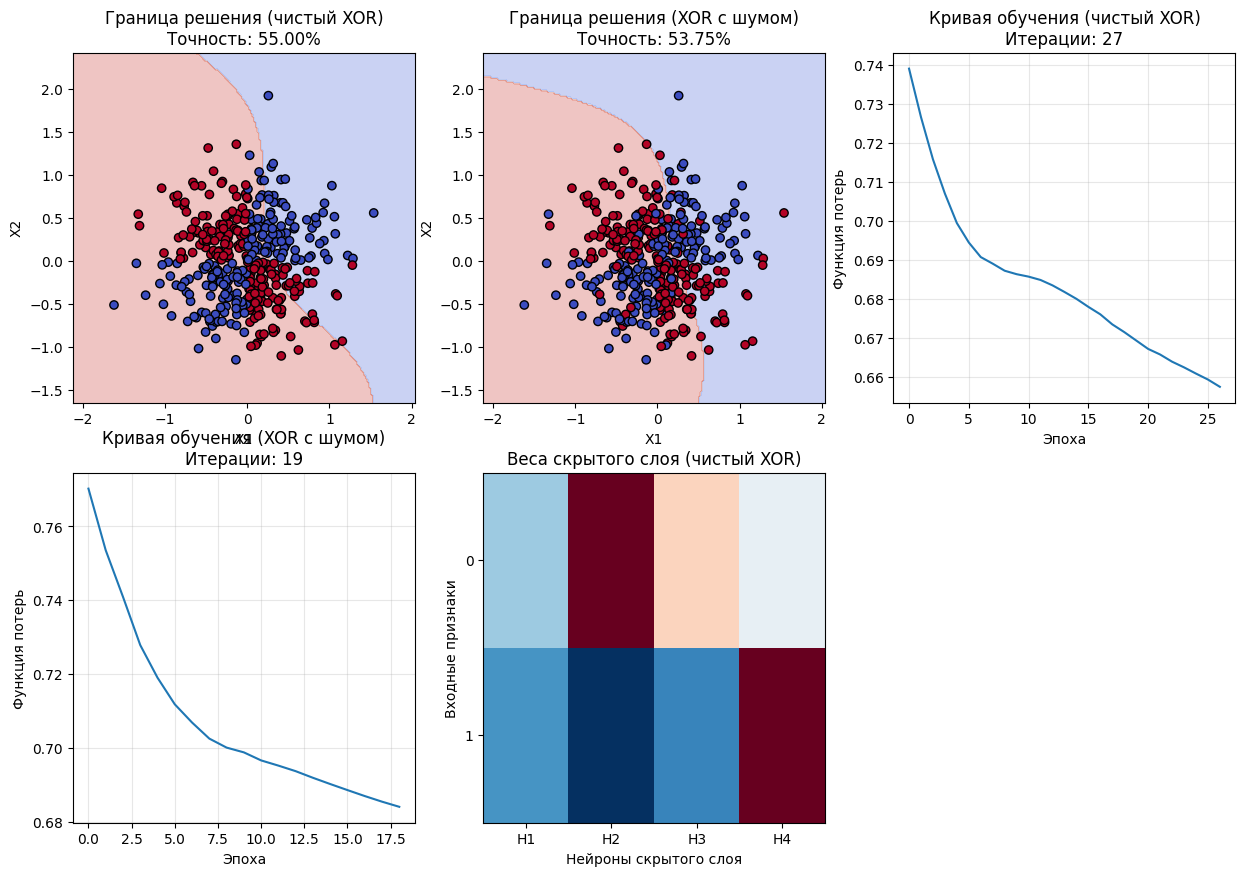

In [4]:
import warnings
warnings.filterwarnings('ignore')

clean_train_acc, clean_test_acc = evaluate_model(
    mlp_clean, X_train_clean, X_test_clean, 
    y_train_clean, y_test_clean, "Чистый XOR"
)

noisy_train_acc, noisy_test_acc = evaluate_model(
    mlp_noisy, X_train_noisy, X_test_noisy,
    y_train_noisy, y_test_noisy, "XOR с шумом"
)

fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(2, 3, 1)
plot_decision_boundary(mlp_clean, X_clean, y_clean, 
                      f'Граница решения (чистый XOR)\nТочность: {clean_test_acc:.2%}', ax1)

ax2 = plt.subplot(2, 3, 2)
plot_decision_boundary(mlp_noisy, X_noisy, y_noisy,
                      f'Граница решения (XOR с шумом)\nТочность: {noisy_test_acc:.2%}', ax2)

ax3 = plt.subplot(2, 3, 3)
plot_learning_curve(mlp_clean.loss_curve_, 
                   f'Кривая обучения (чистый XOR)\nИтерации: {mlp_clean.n_iter_}', ax3)

ax4 = plt.subplot(2, 3, 4)
plot_learning_curve(mlp_noisy.loss_curve_,
                   f'Кривая обучения (XOR с шумом)\nИтерации: {mlp_noisy.n_iter_}', ax4)

ax5 = plt.subplot(2, 3, 5)
visualize_hidden_weights(mlp_clean, 'Веса скрытого слоя (чистый XOR)', ax5)

ax6 = plt.subplot(2, 3, 6)
visualize_hidden_weights(mlp_noisy, 'Веса скрытого слоя (XOR с шумом)', ax6)

plt.tight_layout()
plt.show()